# Initialization, Configurations, and Data Loading

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

BASE_DIR = os.getcwd()

train_path = os.path.join(BASE_DIR, "data", "train.csv")

df = pd.read_csv(train_path)

print(f"Loaded training data. Shape: {df.shape}")
df.head()

Loaded training data. Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Columns Description

The Titanic dataset contains information about passengers aboard the RMS Titanic. The target variable is **Survived**, while the remaining columns are features that may help predict survival.

| Column | Description |
|----------|-------------|
| **PassengerId** | Unique identifier assigned to each passenger. |
| **Survived** | Target variable: `1` if the passenger survived, `0` otherwise. |
| **Pclass** | Passenger ticket class (`1` = First Class, `2` = Second Class, `3` = Third Class). |
| **Name** | Full name of the passenger, including title (e.g., Mr., Mrs., Miss). |
| **Sex** | Passenger gender (`male` or `female`). |
| **Age** | Passenger age in years. Some values are missing. |
| **SibSp** | Number of siblings and spouses traveling with the passenger. |
| **Parch** | Number of parents and children traveling with the passenger. |
| **Ticket** | Passenger ticket number. |
| **Fare** | Ticket fare paid by the passenger. |
| **Cabin** | Cabin number assigned to the passenger. Many values are missing. |
| **Embarked** | Port of embarkation: `C` = Cherbourg, `Q` = Queenstown, `S` = Southampton. |

# Structural Overview and Descriptive Statistics

In [13]:
print("--- Dataset Structural Info ---")
df.info()

print("\n--- Descriptive Statistics Summary ---")
display(df.describe(include='all').T)

--- Dataset Structural Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- Descriptive Statistics Summary ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891,NaN,NaN,NaN,446,257.354,1,223.5,446,668.5,891
Survived,891,NaN,NaN,NaN,0.383838,0.486592,0,0,0,1,1
Pclass,891,NaN,NaN,NaN,2.30864,0.836071,1,2,3,3,3
Name,891,891,"Shellard, Mr. Frederick William",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714,NaN,NaN,NaN,29.6991,14.5265,0.42,20.125,28,38,80
SibSp,891,NaN,NaN,NaN,0.523008,1.10274,0,0,0,1,8
Parch,891,NaN,NaN,NaN,0.381594,0.806057,0,0,0,0,6
Ticket,891,681,CA. 2343,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891,NaN,NaN,NaN,32.2042,49.6934,0,7.9104,14.4542,31,512.329


# Missing Values Mapping and Analysis

--- Missing Values Summary ---


,missing_count,percentage
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2
PassengerId,0,0.0
Survived,0,0.0
Pclass,0,0.0
Name,0,0.0
Sex,0,0.0
SibSp,0,0.0
Parch,0,0.0


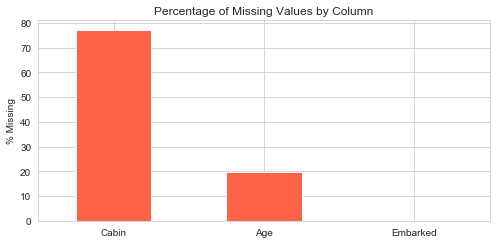

In [14]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'percentage': (df.isna().mean() * 100).round(1),
}).sort_values('missing_count', ascending=False)

print("--- Missing Values Summary ---")
display(missing)

# Plot only columns that actually have missing values
ax = missing[missing['missing_count'] > 0]['percentage'].plot.bar(figsize=(7, 3.5), color='tomato')
ax.set_ylabel('% Missing')
ax.set_title('Percentage of Missing Values by Column')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Target Variable Class Balance (Survived)

Overall Survival Rate in Training Split: 0.384 (342 out of 891)


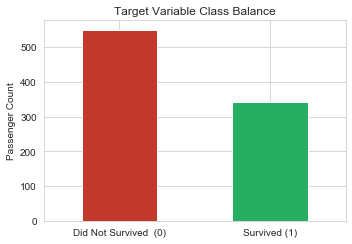

In [15]:
survival_rate = df['Survived'].mean()
print(f"Overall Survival Rate in Training Split: {survival_rate:.3f} ({df['Survived'].sum()} out of {len(df)})")

ax = df['Survived'].value_counts().sort_index().plot.bar(figsize=(5, 3.5), color=['#c0392b', '#27ae60'])
ax.set_xticklabels(['Did Not Survived  (0)', 'Survived (1)'], rotation=0)
ax.set_ylabel('Passenger Count')
ax.set_title('Target Variable Class Balance')
plt.tight_layout()
plt.show()

# Continuous Feature Distributions (Age & Fare)

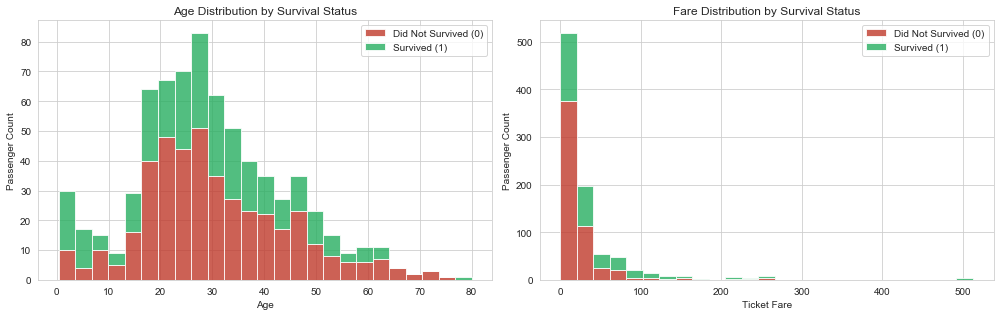

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Separate the data by survival status and drop missing values for plotting
not_survived_age = df[df['Survived'] == 0]['Age'].dropna()
survived_age = df[df['Survived'] == 1]['Age'].dropna()

not_survived_fare = df[df['Survived'] == 0]['Fare'].dropna()
survived_fare = df[df['Survived'] == 1]['Fare'].dropna()

# 1. Age Distribution by Survival Status
axes[0].hist([not_survived_age, survived_age], bins=25, stacked=True, 
             color=['#c0392b', '#27ae60'], alpha=0.8, label=['Did Not Survived (0)', 'Survived (1)'])
axes[0].set_title('Age Distribution by Survival Status')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Passenger Count')
axes[0].legend()

# 2. Ticket Fare Distribution by Survival Status
axes[1].hist([not_survived_fare, survived_fare], bins=25, stacked=True, 
             color=['#c0392b', '#27ae60'], alpha=0.8, label=['Did Not Survived (0)', 'Survived (1)'])
axes[1].set_title('Fare Distribution by Survival Status')
axes[1].set_xlabel('Ticket Fare')
axes[1].set_ylabel('Passenger Count')
axes[1].legend()

plt.tight_layout()
plt.show()

#  Categorical Features vs. Survival Rates

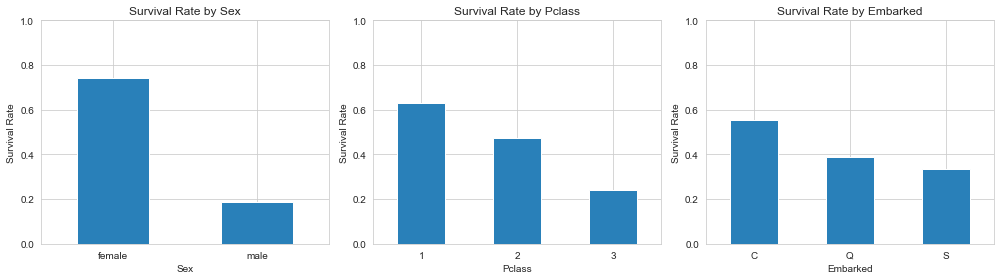

--- Survival Breakdown for Sex ---
        survival_rate  count
Sex                         
female          0.742    314
male            0.189    577

--- Survival Breakdown for Pclass ---
        survival_rate  count
Pclass                      
1               0.630    216
2               0.473    184
3               0.242    491

--- Survival Breakdown for Embarked ---
          survival_rate  count
Embarked                      
C                 0.554    168
Q                 0.390     77
S                 0.337    644



In [17]:
def get_survival_rate(col):
    return df.groupby(col)['Survived'].agg(['mean', 'count']).rename(columns={'mean': 'survival_rate'})

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Sex', 'Pclass', 'Embarked']):
    rates = get_survival_rate(col)['survival_rate']
    rates.plot.bar(ax=ax, color='#2980b9')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Survival Rate')
    ax.set_title(f'Survival Rate by {col}')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Print text breakdown for exact reference
for col in ['Sex', 'Pclass', 'Embarked']:
    print(f"--- Survival Breakdown for {col} ---")
    print(get_survival_rate(col).round(3))
    print()

# Advanced Feature Engineering Exploration

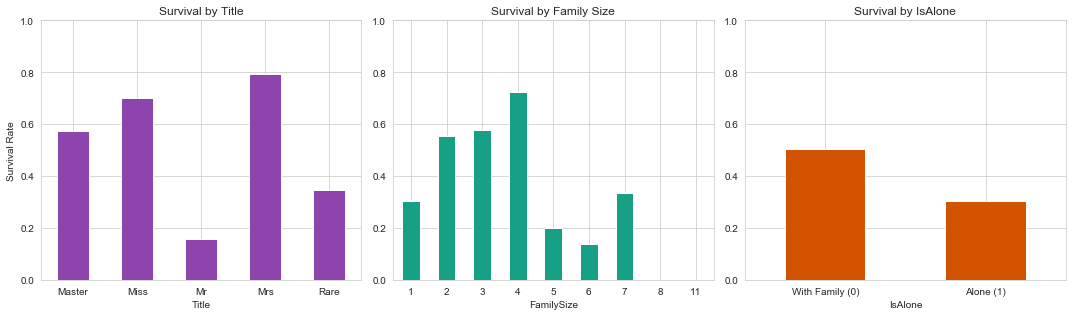

In [18]:
# Create a temporary DataFrame for feature exploration
tmp = df.copy()

# 1. Extract Title from Name
tmp['Title'] = tmp['Name'].str.extract(r',\s*([^.]+)\.')[0].str.strip()
tmp['Title'] = tmp['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
tmp['Title'] = tmp['Title'].where(tmp['Title'].isin(['Mr', 'Mrs', 'Miss', 'Master']), 'Rare')

# 2. Engineer Family Size and IsAlone
tmp['FamilySize'] = tmp['SibSp'] + tmp['Parch'] + 1
tmp['IsAlone'] = (tmp['FamilySize'] == 1).astype(int)

# Visualizing the engineered features
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

tmp.groupby('Title')['Survived'].mean().plot.bar(ax=axes[0], color='#8e44ad')
axes[0].set_title('Survival by Title')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Survival Rate')

tmp.groupby('FamilySize')['Survived'].mean().plot.bar(ax=axes[1], color='#16a085')
axes[1].set_title('Survival by Family Size')
axes[1].set_ylim(0, 1)

tmp.groupby('IsAlone')['Survived'].mean().plot.bar(ax=axes[2], color='#d35400')
axes[2].set_title('Survival by IsAlone')
axes[2].set_xticklabels(['With Family (0)', 'Alone (1)'], rotation=0)
axes[2].set_ylim(0, 1)

for ax in axes: 
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

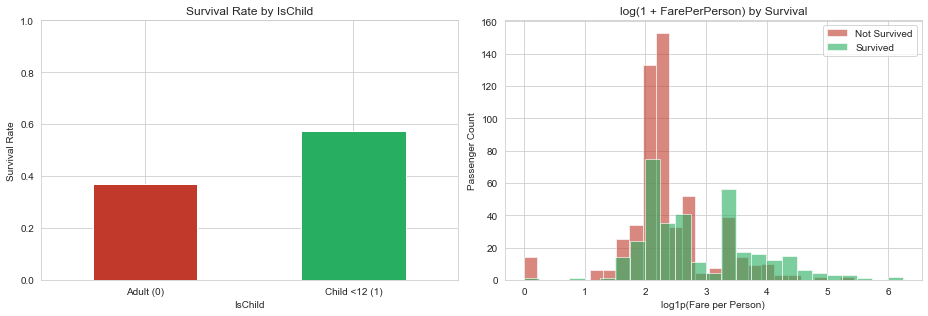

Survival by IsChild:
           mean  count
IsChild              
0        0.368    823
1        0.574     68 

Median FarePerPerson — Not Survived vs Survived:
Survived
0     7.92
1    13.00
Name: FarePerPerson, dtype: float64


In [19]:
# More engineered features: FarePerPerson & IsChild ---
exp = df.copy()

exp['FamilySize'] = exp['SibSp'] + exp['Parch'] + 1
exp['FarePerPerson'] = exp['Fare'] / exp['FamilySize']   # matches preprocessing (computed pre-log)
exp['IsChild'] = (exp['Age'] < 12).astype(int)           # NaN age -> 0 (treated as non-child)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Survival rate by IsChild
exp.groupby('IsChild')['Survived'].mean().plot.bar(
    ax=axes[0],
    color=['#c0392b', '#27ae60']
)

axes[0].set_title('Survival Rate by IsChild')
axes[0].set_xticklabels(['Adult (0)', 'Child <12 (1)'], rotation=0)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Survival Rate')

# FarePerPerson by survival (log scale, since it inherits Fare's right skew)
for label, color, name in [
    (0, '#c0392b', 'Not Survived'),
    (1, '#27ae60', 'Survived')
]:
    vals = exp.loc[
        exp['Survived'] == label,
        'FarePerPerson'
    ].dropna()

    axes[1].hist(
        np.log1p(vals),
        bins=25,
        alpha=0.6,
        color=color,
        label=name
    )

axes[1].set_title('log(1 + FarePerPerson) by Survival')
axes[1].set_xlabel('log1p(Fare per Person)')
axes[1].set_ylabel('Passenger Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(
    "Survival by IsChild:\n",
    exp.groupby('IsChild')['Survived']
       .agg(['mean', 'count'])
       .round(3),
    "\n"
)

print("Median FarePerPerson — Not Survived vs Survived:")
print(
    exp.groupby('Survived')['FarePerPerson']
       .median()
       .round(2)
)

# Correlation Matrix and Feature Interdependencies

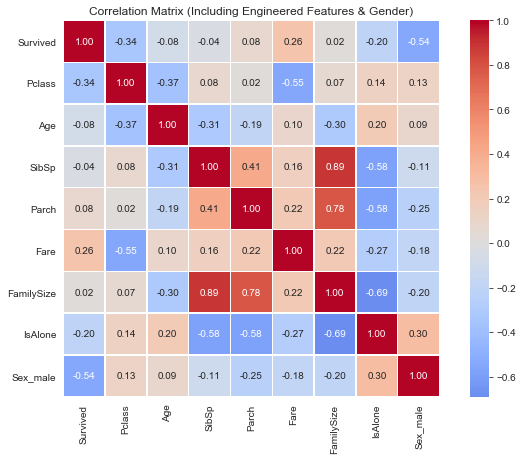

In [20]:
# Select columns for correlation and include encoded text feature
num_df = tmp[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']].copy()
num_df['Sex_male'] = (tmp['Sex'] == 'male').astype(int)

# Filter automatically to ensure compatibility with older pandas versions
numerical_only = num_df.select_dtypes(include=[np.number])
corr_matrix = numerical_only.corr()

plt.figure(figsize=(9, 6.5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix (Including Engineered Features & Gender)')
plt.tight_layout()
plt.show()

### Final Exploratory Data Analysis (EDA) Insights

Based on the Exploratory Data Analysis (EDA), the following insights will directly guide our data preparation and model architecture pipeline:

| Feature / Finding | EDA Insight | Preprocessing & Engineering Decision |
| :--- | :--- | :--- |
| **Age** | ~20% missing values; heavily correlates with passenger titles. | Impute missing values using the **median Age per Title** (computed on Train). |
| **Embarked** | Only 2 missing rows. | Impute missing values with the **Mode (most frequent port)** from the training set. |
| **Cabin** | ~77% missing values; extremely sparse and introduces high dimensionality. | **Drop the feature entirely** to prevent noise and overfitting in the Neural Network. |
| **Fare** | Heavily right-skewed with extreme outliers. | Apply **log1p transformation** to handle skewness, and normalize inputs using **StandardScaler**. |
| **Categorical Predictors** | `Sex`, `Pclass`, and `Title` show massive survival gaps. | Keep and encode them using **One-Hot Encoding** with strict structural matching. |
| **Family Columns** | `SibSp` and `Parch` show distinct patterns when combined. | Engineer **FamilySize** (`SibSp + Parch + 1`) and a binary **IsAlone** feature. |
| **FarePerPerson** | Per-capita fare separates survivors even within a class (wealth proxy beyond Pclass). | Engineer `Fare / FamilySize`, then `log1p` + StandardScaler. |
| **IsChild (Age < 12)** | Children show a higher survival rate. | Binary `Age < 12` flag. |
| **Class Imbalance** | ~38% positive class (Survived = 1). |Implement class weights (pos_weight) in the loss;|

